# Hello World - Coupled Magnetoelastic Theory
## Magnetoelastic Hysteresis

This notebook demonstrates the code used to reproduce the results in: Sablik, M.J.; Jiles, D.C., "Coupled magnetoelastic theory of magnetic and magnetostrictive hysteresis," in Magnetics, IEEE Transactions on , vol.29, no.4, pp.2113-2123, Jul 1993. 

Approximate reproduction of stress-dependent magnetization hysteresis curves
similar to the figure shown in the 1993 IEEE Transactions on Magnetics paper.

This is a practical, tunable implementation based on:
    1. Jiles–Atherton-like magnetization hysteresis
    2. Stress added through an effective field term
    3. Magnetostriction computed from magnetization


B. Howard

## Libraries

In [1]:
#import sys
#!{sys.executable} -m pip install subprocess

In [2]:
import sys
import os

# Add parent directory to path to import magnetoelasticsensor package
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

### Do the libraries we need exist?

In [3]:
import subprocess
import sys
import math

# Install required packages
required_packages = [
    'numpy',
    'pandas',
    'matplotlib',
]

print("Checking and installing required libraries...")
print("=" * 70)

for package in required_packages:
    try:
        __import__(package)
        print(f"✓ {package:12} is already installed")
    except ImportError:
        print(f"  Installing {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
        print(f"✓ {package:12} installed successfully")

print("=" * 70)
print("✓ All required libraries are available!\n")

Checking and installing required libraries...
✓ numpy        is already installed
✓ pandas       is already installed
✓ matplotlib   is already installed
✓ All required libraries are available!



### Bring in the libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from magnetoelasticsensor.anhyst_iso import (
    anhysteretic_magnetization,
    anhysteretic_magnetization_differential,
)
from magnetoelasticsensor.ja_solver import ja_solver
from magnetoelasticsensor.ja_props import JAProps


### Constants

In [5]:
MU0 = JAProps.MU0  # H/m

### Functions

## 1. Plot the results

Computed M_an at H = 300 A/m: 144738.354822 A/m
Expected M_an from test:           144738.354822 A/m
Absolute error:                    0.000000e+00 A/m


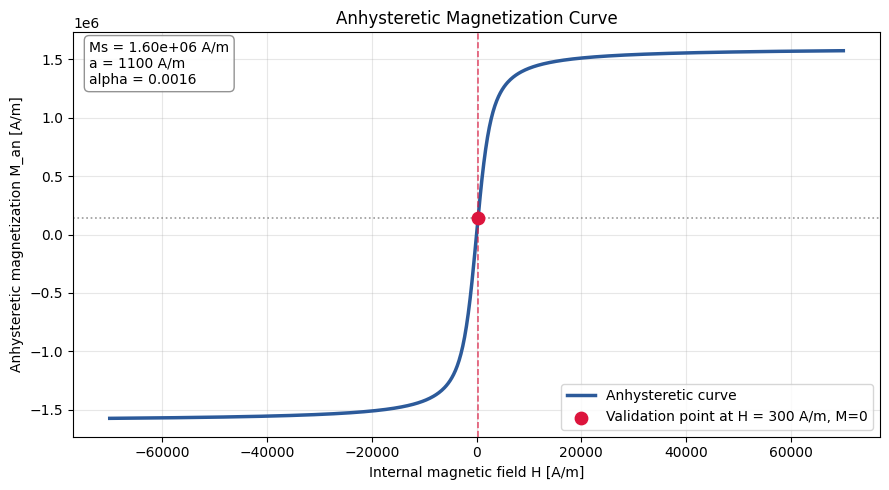

In [6]:
# Jiles-Atherton model parameters — shared across all plots in this notebook
props = JAProps(
    ms=1.6e6,
    a=1100,
    alpha=0.0016,
    k=400.0,
    c=0.2,
)


# Anhysteretic model parameters — shared across all plots in this notebook
props_anhysteretic = JAProps(
    ms=1.6e6,
    a=1100,
    alpha=0.0016,
    k=1.0,
    c=0.2,
)

m = 0.0  # initial (reference) magnetization for anhysteretic sweep

# Sweep the internal magnetic field to trace the anhysteretic curve
h_values = np.linspace(-70000, 70000, 801)
man_values = anhysteretic_magnetization(
    h=h_values,
    m=m,
    props=props,
)

# Validation point from the unit test
h_test = 300.0
man_expected = 144738.3548215022
man_test = anhysteretic_magnetization(
    h=h_test,
    m=m,
    props=props,
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(h_values, man_values, color='#2C5A9A',linewidth=2.5, label='Anhysteretic curve')
ax.scatter(
    [h_test],
    [man_test],
    color='crimson',
    s=80,
    zorder=3,
    label='Validation point at H = 300 A/m, M=0',
)
ax.axvline(h_test, color='crimson', linestyle='--', linewidth=1.2, alpha=0.7)
ax.axhline(man_expected, color='gray', linestyle=':', linewidth=1.2, alpha=0.8)

param_text = '\n'.join([
    f'Ms = {props.ms:.2e} A/m',
    f'a = {props.a:.0f} A/m',
    f'alpha = {props.alpha:.4f}',
])
ax.text(
    0.02,
    0.98,
    param_text,
    transform=ax.transAxes,
    fontsize=10,
    va='top',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.5'),
)

ax.set_title('Anhysteretic Magnetization Curve')
ax.set_xlabel('Internal magnetic field H [A/m]')
ax.set_ylabel('Anhysteretic magnetization M_an [A/m]')
ax.grid(True, alpha=0.3)
ax.legend()

print(f'Computed M_an at H = {h_test:.0f} A/m: {man_test:.6f} A/m')
print(f'Expected M_an from test:           {man_expected:.6f} A/m')
print(f'Absolute error:                    {abs(man_test - man_expected):.6e} A/m')

plt.tight_layout()
plt.show()


## 2. Plot the anhysteretic derivative

Computed dM_an/dH at H = 300 A/m: 477.720139
Origin limit Ms/(3a):                     484.848485


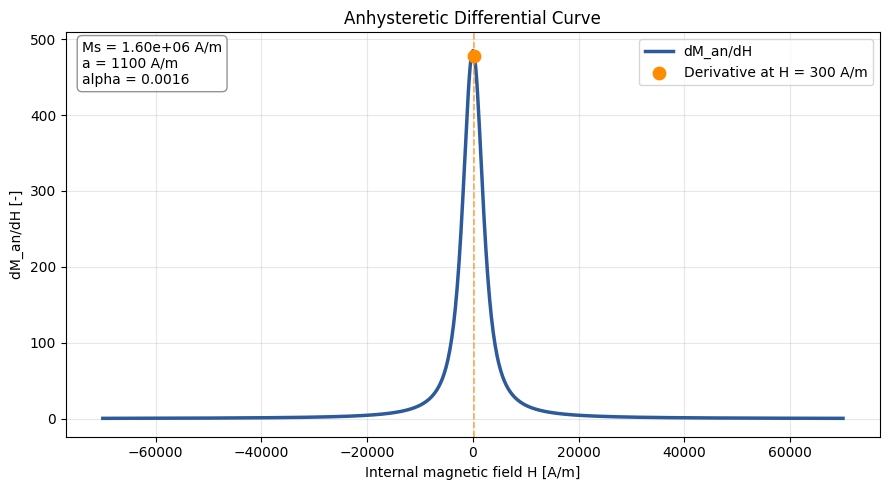

In [7]:
# Reuse the same sweep and props from the previous cell
h_values = np.linspace(-70000, 70000, 801)
dman_dh_values = anhysteretic_magnetization_differential(
    h=h_values,
    m=m,
    props=props,
)

# Validation point from dMan/dH limit and closed-form checks
h_test = 300.0
dman_dh_test = anhysteretic_magnetization_differential(
    h=h_test,
    m=m,
    props=props,
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(h_values, dman_dh_values, linewidth=2.5, color='#2C5A9A', label='dM_an/dH')
ax.scatter(
    [h_test],
    [dman_dh_test],
    color='darkorange',
    s=80,
    zorder=3,
    label='Derivative at H = 300 A/m',
)
ax.axvline(h_test, color='darkorange', linestyle='--', linewidth=1.2, alpha=0.7)

param_text = '\n'.join([
    f'Ms = {props.ms:.2e} A/m',
    f'a = {props.a:.0f} A/m',
    f'alpha = {props.alpha:.4f}',
])
ax.text(
    0.02,
    0.98,
    param_text,
    transform=ax.transAxes,
    fontsize=10,
    va='top',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.5'),
)

ax.set_title('Anhysteretic Differential Curve')
ax.set_xlabel('Internal magnetic field H [A/m]')
ax.set_ylabel('dM_an/dH [-]')
ax.grid(True, alpha=0.3)
ax.legend()

print(f'Computed dM_an/dH at H = {h_test:.0f} A/m: {dman_dh_test:.6f}')
print(f'Origin limit Ms/(3a):                     {props.ms / (3.0 * props.a):.6f}')

plt.tight_layout()
plt.show()


## 3. Plot full hysteresis loop with anhysteretic overlay

Loop points: 311
M range: [-1337.13, 1337.13] kA/m


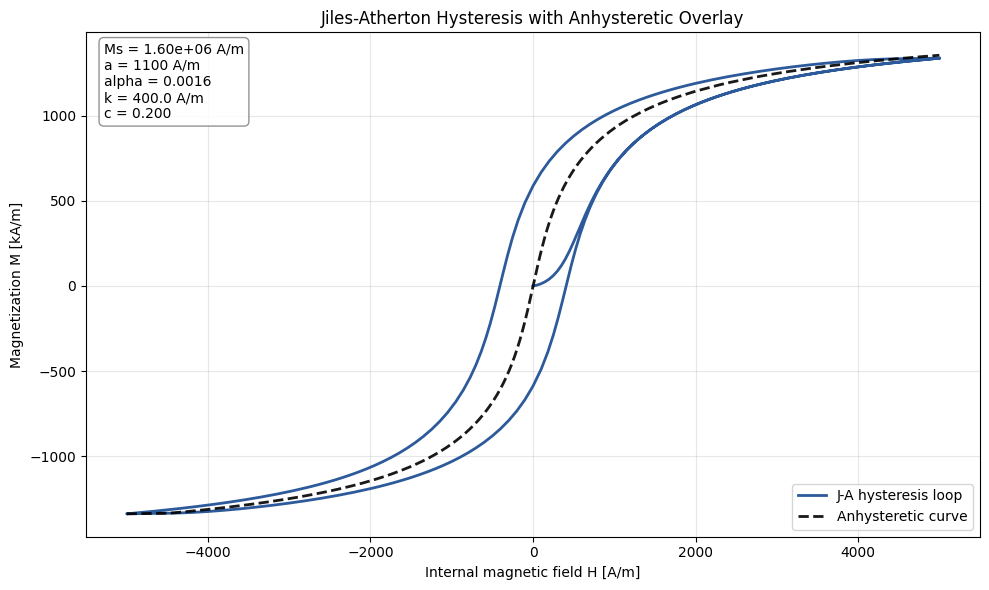

In [8]:
# Full-loop Jiles-Atherton hysteresis trajectory using ja_solver
# Plot the initial magnetization curves to match Fig. (9) in [2]
h_max = 5000.0
solver_type = 2  # RK45

# Segment 1: 0 -> +Hmax
h1, m1 = ja_solver(
    props=props,
    h_start=0.0,
    h_end=h_max,
    m0=0.0,
    solver_type=solver_type,
)

# Segment 2: +Hmax -> -Hmax
h2, m2 = ja_solver(
    props=props,
    h_start=h_max,
    h_end=-h_max,
    m0=float(m1[-1]),
    solver_type=solver_type,
)

# Segment 3: -Hmax -> +Hmax (close the major loop)
h3, m3 = ja_solver(
    props=props,
    h_start=-h_max,
    h_end=h_max,
    m0=float(m2[-1]),
    solver_type=solver_type,
)

# Concatenate, removing duplicated segment boundary points
h_loop = np.concatenate([h1, h2[1:], h3[1:]])
m_loop = np.concatenate([m1, m2[1:], m3[1:]])

# Anhysteretic reference curve overlay (same H-span)
h_an, m_an = ja_solver(
    props=props_anhysteretic,
    h_start=-h_max,
    h_end=h_max,
    m0=float(m2[-1]),
    solver_type=solver_type,
)

# Scale magnetization to kA/m for clearer y-axis values
m_loop_ka = m_loop / 1000.0
m_an_ka = m_an / 1000.0

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(h_loop, m_loop_ka, color='#2C5A9A', linewidth=2.0, label='J-A hysteresis loop')
ax.plot(
    h_an,
    m_an_ka,
    color='black',
    linestyle='--',
    linewidth=2.0,
    alpha=0.9,
    label='Anhysteretic curve',
)

param_text = '\n'.join([
    f'Ms = {props.ms:.2e} A/m',
    f'a = {props.a:.0f} A/m',
    f'alpha = {props.alpha:.4f}',
    f'k = {props.k:.1f} A/m',
    f'c = {props.c:.3f}',
])
ax.text(
    0.02,
    0.98,
    param_text,
    transform=ax.transAxes,
    fontsize=10,
    va='top',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.5'),
)

ax.set_title('Jiles-Atherton Hysteresis with Anhysteretic Overlay')
ax.set_xlabel('Internal magnetic field H [A/m]')
ax.set_ylabel('Magnetization M [kA/m]')
ax.grid(True, alpha=0.3)
ax.legend()

print(f'Loop points: {h_loop.size}')
print(f'M range: [{np.min(m_loop_ka):.2f}, {np.max(m_loop_ka):.2f}] kA/m')

plt.tight_layout()
plt.show()


## 4. Plot full hysteresis loop as magnetic flux density B

B range: [-1.6866, 1.6866] T


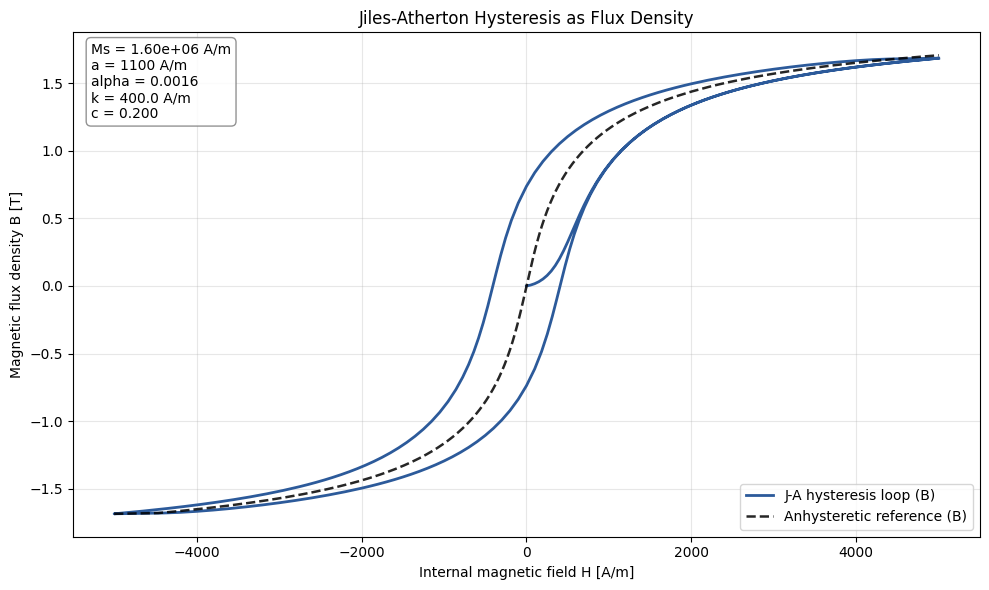

In [9]:
# Convert the full hysteresis loop from magnetization to flux density
b_loop = MU0 * (h_loop + m_loop)
b_ref = MU0 * (h_an + m_an)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(h_loop, b_loop, color='#2C5A9A', linewidth=2.0, label='J-A hysteresis loop (B)')
ax.plot(
    h_an,
    b_ref,
    color='black',
    linestyle='--',
    linewidth=1.8,
    alpha=0.85,
    label='Anhysteretic reference (B)',
)

param_text = '\n'.join([
    f'Ms = {props.ms:.2e} A/m',
    f'a = {props.a:.0f} A/m',
    f'alpha = {props.alpha:.4f}',
    f'k = {props.k:.1f} A/m',
    f'c = {props.c:.3f}',
])
ax.text(
    0.02,
    0.98,
    param_text,
    transform=ax.transAxes,
    fontsize=10,
    va='top',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.5'),
)

ax.set_title('Jiles-Atherton Hysteresis as Flux Density')
ax.set_xlabel('Internal magnetic field H [A/m]')
ax.set_ylabel('Magnetic flux density B [T]')
ax.grid(True, alpha=0.3)
ax.legend()

print(f'B range: [{np.min(b_loop):.4f}, {np.max(b_loop):.4f}] T')

plt.tight_layout()
plt.show()


## 5. Stress sweep: B-H hysteresis shift vs stress

This section sweeps stress \(\sigma_0\) and plots the full hysteresis loop as magnetic flux density:

\[
B = \mu_0(H + M)
\]

Stress enters through the effective field term used by the model.

Stress sweep complete for sigma0 values [MPa]: [-20.0, 0.0, 20.0]


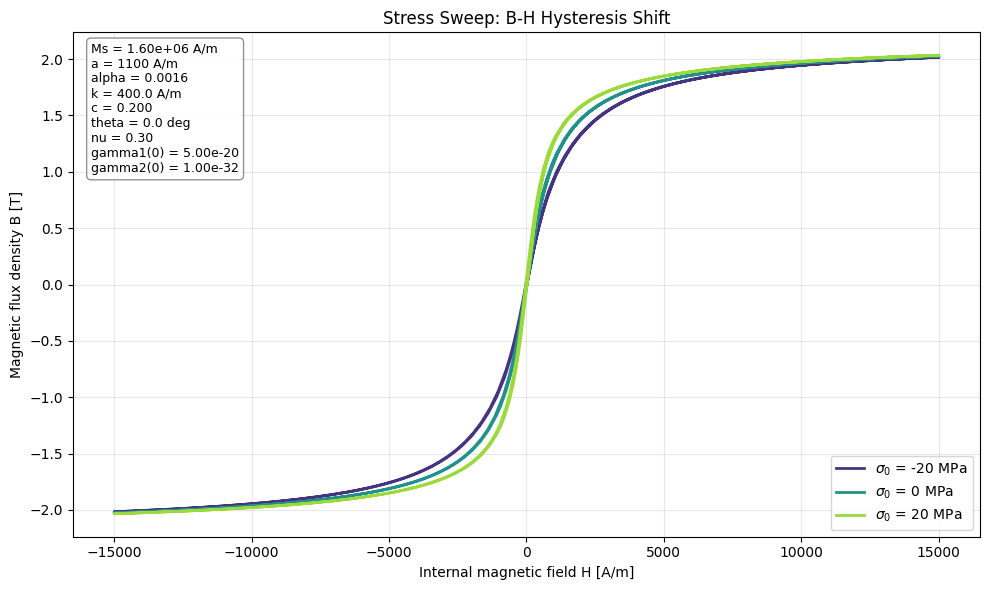

In [29]:
# Sweep stress and plot B-H hysteresis loops
stress_values_mpa = [-20.0, 0.0, 20.0]  # MPa
theta_deg = 0.0
nu = 0.30

# Base magnetoelastic coefficients at sigma0 = 0
gamma1_intercept_ref = 4.0e-18
gamma2_intercept_ref = 2.0e-30

# Linear stress dependence of gamma1 and gamma2
gamma1_sigma_slope = -2.0e-26
gamma2_sigma_slope = -5.0e-39

h_max_local = 15000.0
#solver_type_local = solver_type if 'solver_type' in globals() else 2
solver_type_local = 3

fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(stress_values_mpa)))

for color, sigma_mpa in zip(cmap, stress_values_mpa):
    sigma_pa = sigma_mpa * 1.0e6
    props_sigma = JAProps(
        ms=1.7e6,
        a=1000,
        alpha=0.001,
        k=20,
        c=0.1,
        theta=np.deg2rad(theta_deg),
        nu=nu,
        sigma0=0.0,
        gamma1_intercept=gamma1_intercept_ref,
        gamma2_intercept=gamma2_intercept_ref,
        gamma1_sigma_slope=gamma1_sigma_slope,
        gamma2_sigma_slope=gamma2_sigma_slope,
    )
    props_sigma.sigma0 = sigma_pa

    # Solve one full loop in three monotonic segments
    h1_s, m1_s = ja_solver(
        props=props_sigma,
        h_start=0.0,
        h_end=h_max_local,
        m0=0.0,
        solver_type=solver_type_local,
    )
    h2_s, m2_s = ja_solver(
        props=props_sigma,
        h_start=h_max_local,
        h_end=-h_max_local,
        m0=float(m1_s[-1]),
        solver_type=solver_type_local,
    )
    h3_s, m3_s = ja_solver(
        props=props_sigma,
        h_start=-h_max_local,
        h_end=h_max_local,
        m0=float(m2_s[-1]),
        solver_type=solver_type_local,
    )

    h_loop_s = np.concatenate([h1_s, h2_s[1:], h3_s[1:]])
    m_loop_s = np.concatenate([m1_s, m2_s[1:], m3_s[1:]])
    b_loop_s = MU0 * (h_loop_s + m_loop_s)

    ax.plot(
        h_loop_s,
        b_loop_s,
        color=color,
        linewidth=2.0,
        label=rf'$\sigma_0$ = {sigma_mpa:.0f} MPa',
    )

param_text = '\n'.join([
    f'Ms = {props.ms:.2e} A/m',
    f'a = {props.a:.0f} A/m',
    f'alpha = {props.alpha:.4f}',
    f'k = {props.k:.1f} A/m',
    f'c = {props.c:.3f}',
    f'theta = {theta_deg:.1f} deg',
    f'nu = {nu:.2f}',
    f'gamma1(0) = {gamma1_ref:.2e}',
    f'gamma2(0) = {gamma2_ref:.2e}',
])
ax.text(
    0.02,
    0.98,
    param_text,
    transform=ax.transAxes,
    fontsize=9,
    va='top',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.5'),
)

ax.set_title('Stress Sweep: B-H Hysteresis Shift')
ax.set_xlabel('Internal magnetic field H [A/m]')
ax.set_ylabel('Magnetic flux density B [T]')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')

print('Stress sweep complete for sigma0 values [MPa]:', stress_values_mpa)
plt.tight_layout()
plt.show()
